In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 800
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 4
smoothIC = True
timeLimit = 0.15

L = 2
dim = 1
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

config = SimulationConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland2,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta4,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = False,
    cflFactor=0.3,
)

diffusionParams = DiffusionParameters()
diffusionParams.c_s = 1
diffusionParams.C_l = 1
diffusionParams.C_q = 0
diffusionParams.Cu_l = 1
diffusionParams.Cu_q = 0
diffusionParams.K = 1.0
diffusionParams.thermalConductivity = 0.5
diffusionParams.viscosityTerm = 7
diffusionParams.thermalConducitiyTerm = 9
diffusionParams.scaleBeta = False
diffusionParams.monaghanSwitch = True
diffusionParams.correctXi = True

compressibleSPHConfig = CompressibleSPHConfig(
    gamma = gamma,
    rho0 = leftState.rho,
    diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)


In [3]:
compSystem = buildSod1D(
    nx,
    samplingRatio,
    leftState,
    rightState,
    gamma, config,
    smoothIC
)

Left particles: 800, Right particles: 200
Module sphWarpCore.radiusSearch.wp_compactHash a7913c2 load on device 'cuda:0' took 12.18 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid 1ca7812 load on device 'cuda:0' took 10.16 ms  (cached)
Module sphWarpCore.operations.wp_density 896c489 load on device 'cuda:0' took 7.29 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_omega 3a4c241 load on device 'cuda:0' took 5.98 ms  (cached)


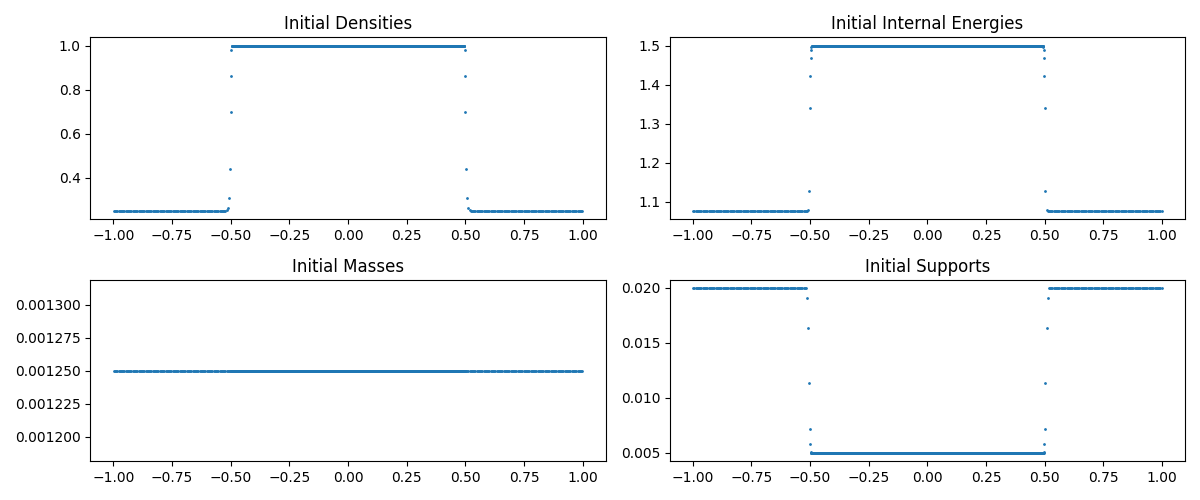

In [4]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], compSystem.state.positions, compSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], compSystem.state.positions, compSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compSystem.state.positions, compSystem.state.supports, title = 'Initial Supports')
fig.tight_layout()

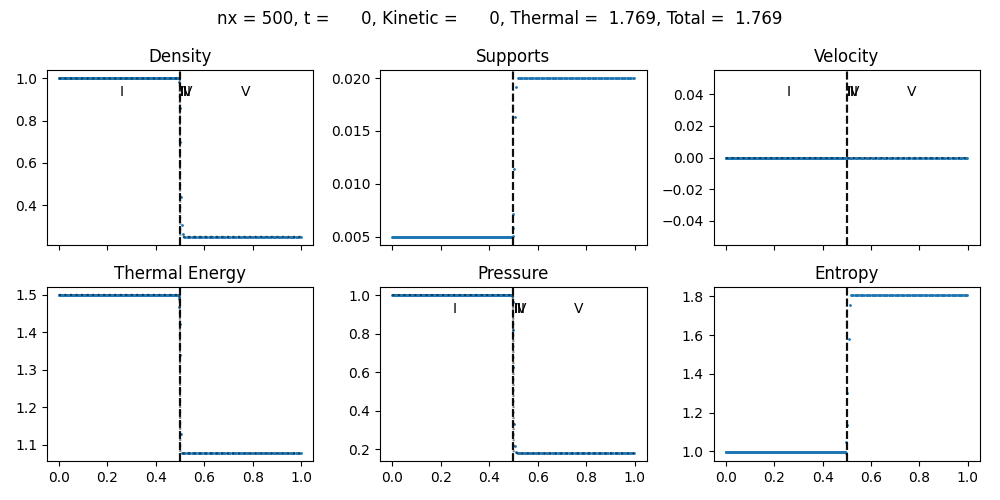

In [5]:
plotSod(compSystem.state, None, None, gamma, leftState, rightState, plotReference = True, plotLabels = True, scatter = True, t_ = compSystem.t)

In [6]:
update, adjacency, state = compressibleSPH_Monaghan(compSystem, config.dt, config, compressibleSPHConfig, verbose = True)

Module sphWarpCore.operations.wp_gradient f0134b6 load on device 'cuda:0' took 13.66 ms  (cached)
Module sphWarpCore.operations.wp_divergence 5883463 load on device 'cuda:0' took 10.62 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_diffusion d16c20f load on device 'cuda:0' took 10.64 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_conductivity 36b640e load on device 'cuda:0' took 8.77 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_dissipation 1793859 load on device 'cuda:0' took 9.74 ms  (cached)


In [7]:


with profile(activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA], record_shapes=True) as prof:

    stepResult = integrator.function(
        state = compSystem,
        f = compressibleSPH_Monaghan,
        dt = config.dt,
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
    )

print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=10))
prof.export_chrome_trace("warp_trace.json")

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                  [Integration] Butcher         1.73%       1.253ms        99.81%      72.219ms      72.219ms       0.000us         0.00%       2.682ms       2.682ms             1  
                              [Integration] Update Step         2.40%       1.739ms        83.50%      60.423ms      15.106ms       0.000us         0.00%       2.507ms     626.872us             4  
         

In [8]:


runningState = compSystem.initializeNewState()
for i in (tq := tqdm(range(256), leave = True)):
    result = integrator.function(
        state = runningState,
        f = compressibleSPH_Monaghan,
        dt = config.dt,
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
    )

    runningState = result.state

  0%|          | 0/256 [00:00<?, ?it/s]

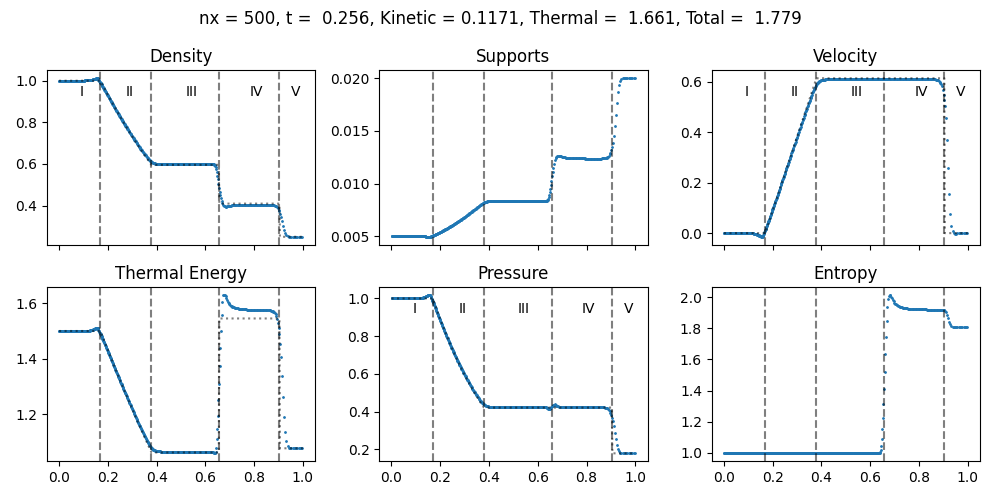

In [9]:
plotSod(runningState.state, None, None, gamma, leftState, rightState, plotReference = True, plotLabels = True, scatter = True, t_ = runningState.t)